# 03 · Previsão de volume (Prophet)

**Projeto:** Cronos · Challenge FIAP 2026 com Locaweb
**Autores:** Ana Beatriz Costa de Oliveira · Hygor Abrantes · Igor Vignola
**Criado em:** 28/07/2026 · **Atualizado em:** 17/08/2026

Treino e validação do modelo de previsão de volume diário de incidentes elegíveis ao KPI, por
prioridade (P2 e P3), com horizonte de D+1 a D+7. O Prophet é comparado contra dois baselines
ingênuos e contra uma regressão linear de calendário, em duas validações: corte out-of-time e
rolling backtest.

**Entrada:** `data/interim/incidentes_kpi.parquet`, gerado pelo notebook 02.
**Saída:** figuras em `notebooks/figures/03_previsao_volume/`.
**Bibliotecas:** pandas, numpy, matplotlib, prophet, holidays, scikit-learn, scipy (Python 3.11+).

In [1]:
# Stdlib
import glob
import itertools
import logging
import os
import warnings
from pathlib import Path

# Third-party
import holidays
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression

# Configurações
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Raiz do repositório (permite executar o notebook de qualquer diretório)
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'interim').exists())

# Windows: o cmdstan usado pelo Prophet precisa da pasta 'tbb' no PATH antes do primeiro import
_tbb = [d for d in glob.glob(str(RAIZ / '.venv' / 'Lib' / 'site-packages' / 'prophet' / 'stan_model' / '**' / 'tbb'),
        recursive=True) if os.path.isdir(d)]
if _tbb:
    os.environ['PATH'] = os.path.abspath(_tbb[0]) + os.pathsep + os.environ['PATH']

from prophet import Prophet

# Silencia os logs de ajuste do cmdstan (poluem o output a cada re-treino)
for _lg in ('prophet', 'cmdstanpy'):
    logging.getLogger(_lg).setLevel(logging.ERROR)
    logging.getLogger(_lg).propagate = False
logging.getLogger('cmdstanpy').disabled = True

## 1. Setup

Estilo dos gráficos, caminhos, funções de métrica e formatação, e o controle de semente da banda
do Prophet.

In [2]:
COR = {'preto': '#000000', 'cinza_esc': '#444444', 'cinza': '#888888',
       'accent': '#2563EB', 'danger': '#DC2626', 'ambar': '#D97706'}
mpl.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': '#444444', 'axes.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12.5, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.grid': True, 'axes.axisbelow': True, 'grid.color': '#E5E5E5', 'grid.linewidth': 0.5,
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'DejaVu Sans'], 'font.size': 10,
    'legend.frameon': False,
})
plt.rcParams['axes.grid.axis'] = 'y'

PARQUET = RAIZ / 'data' / 'interim' / 'incidentes_kpi.parquet'
assert PARQUET.exists(), 'parquet não encontrado. Execute o 02_base_kpi.ipynb antes.'

FIG_DIR = RAIZ / 'notebooks' / 'figures' / '03_previsao_volume'
FIG_DIR.mkdir(parents=True, exist_ok=True)

def mae(real, prev):
    """Erro absoluto médio, em incidentes por dia."""
    return float(np.mean(np.abs(np.asarray(real, float) - np.asarray(prev, float))))

def fmt(x, casas=2):
    """Formata número no padrão PT-BR (vírgula decimal)."""
    return f'{x:.{casas}f}'.replace('.', ',')

def fmt_int(x):
    """Formata inteiro no padrão PT-BR (ponto de milhar)."""
    return f'{int(x):,}'.replace(',', '.')

def salvar_fig(fig, nome):
    fig.savefig(FIG_DIR / f'{nome}.png', dpi=150, bbox_inches='tight')

# O ponto previsto pelo Prophet (yhat) é determinístico: o L-BFGS converge para o mesmo MAP.
# A banda, não: yhat_lower e yhat_upper vêm de amostragem posterior, que usa o RNG global do
# numpy. Sem semente, a cobertura medida oscila alguns pontos percentuais entre execuções.
SEMENTE = 42

def prever(modelo, datas):
    """Previsão do Prophet com a banda reproduzível."""
    np.random.seed(SEMENTE)
    return modelo.predict(pd.DataFrame({'ds': datas}))

## 2. Carga dos dados

Leitura da base elegível ao KPI gravada pelo notebook 02.

In [3]:
df_kpi = pd.read_parquet(PARQUET)
print(f'Base carregada: {fmt_int(len(df_kpi))} incidentes elegíveis ao KPI')

Base carregada: 25.600 incidentes elegíveis ao KPI


## 3. Visão geral

Período coberto, composição por ano e por prioridade. A validação de integridade da base fica no
notebook 02.

In [4]:
display(df_kpi.head())
print(f"Período: {df_kpi['dia'].min():%d/%m/%Y} a {df_kpi['dia'].max():%d/%m/%Y}")
print('\nElegíveis por ano:')
print(df_kpi['ano'].value_counts().sort_index().to_string())
print('\nElegíveis por prioridade (2025):')
print(df_kpi[df_kpi['ano'] == 2025]['Prioridade'].value_counts().to_string())
print()
_pa = df_kpi['ano'].value_counts().sort_index()
print(f'elegíveis em 2025: {_pa.get(2025, 0)/len(df_kpi)*100:.1f}% do total')
print(f'2023 e 2024 somam {_pa.reindex([2023, 2024]).sum():.0f} registros')


,Número,Prioridade,Produto,Categoria,Subcategoria,Grupo designado,Item de configuração,Aberto,Resolvido,Encerrado,Duração,Código de fechamento,Descrição resumida,Solução,Aberto por,Incidente Pai,Status,Entrou para KPI?,KPI Violado?,dia,dia_semana,hora,ano,mes
0,INC8654075,2 - Alta,lrel,cat85,sub81,Team09,IC00055,2025-12-31 18:06:15,2025-12-31 19:36:58,2025-12-31 20:13:42,5443,Falha de Aplicação,IC00731 locaweb em instalação,Contorno,Manual,None,Encerrado,SIM,NAO,2025-12-31,2,18,2025,12
1,INC8653993,2 - Alta,lhvp,cat73,sub369,Team14,IC00067,2025-12-31 14:45:31,2025-12-31 15:19:43,2025-12-31 15:52:08,2052,Falha de Sistema Operacional,[IC00067] Servidor inacessível,Contorno,Manual,None,Encerrado,SIM,NAO,2025-12-31,2,14,2025,12
2,INC8653923,2 - Alta,lhco,cat71,sub7,Team14,IC00082,2025-12-31 11:43:57,2025-12-31 12:06:59,2025-12-31 12:08:36,1382,Falha de Sistema Operacional,Problem: Check: Varnish Type: tcp on Port: 80 ...,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,11,2025,12
3,INC8653899,2 - Alta,lssl,cat102,sub362,Team14,IC00083,2025-12-31 11:13:53,2025-12-31 11:38:35,2025-12-31 11:55:53,1482,Falha de Sistema Operacional,Problem: Pool: /Common/xpl_lw-ssl_panel_https ...,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,11,2025,12
4,INC8653798,2 - Alta,lrev,cat97,sub39,Team14,IC00095,2025-12-31 07:15:16,2025-12-31 07:36:27,2025-12-31 07:52:03,1271,Falha de Banco de Dados,Problem: Check MS SQL Response Test,Contorno,Monitoramento,None,Encerrado,SIM,NAO,2025-12-31,2,7,2025,12


Período: 02/01/2023 a 31/12/2025

Elegíveis por ano:
ano
2023       87
2024      357
2025    25156

Elegíveis por prioridade (2025):
Prioridade
3 - Média    19997
2 - Alta      5159

elegíveis em 2025: 98.3% do total
2023 e 2024 somam 444 registros


## 4. Modelagem

A previsão usa apenas 2025, que concentra 98,3% dos elegíveis; 2023 e 2024 somam 444 registros,
insuficientes para treino e validação. P2 e P3 são modeladas como séries separadas, porque os
volumes diferem por um fator de quase 4 e uma série única diluiria o P2.

### 4.1 Séries diárias por prioridade

Contagem diária de cada prioridade em 2025, reindexada no calendário do ano, com os dias
coloridos por tipo: útil, fim de semana e feriado.

In [5]:
idx_2025 = pd.date_range('2025-01-01', '2025-12-31', freq='D')

def serie_diaria(prefixo_prioridade):
    """Contagem diária de incidentes elegíveis da prioridade, com dias vazios = 0."""
    d = df_kpi[(df_kpi['ano'] == 2025) &
               (df_kpi['Prioridade'].astype(str).str.startswith(prefixo_prioridade))]
    return d.groupby('dia').size().reindex(idx_2025, fill_value=0)

serie_p2 = serie_diaria('2')
serie_p3 = serie_diaria('3')
SERIES = [('P3', serie_p3), ('P2', serie_p2)]

for tag, s in SERIES:
    print(f'{tag}: média {fmt(s.mean(), 1)}/dia | mín {s.min()} | máx {s.max()} | total no ano {fmt_int(s.sum())}')

P3: média 54,8/dia | mín 1 | máx 168 | total no ano 19.997
P2: média 14,1/dia | mín 3 | máx 43 | total no ano 5.159


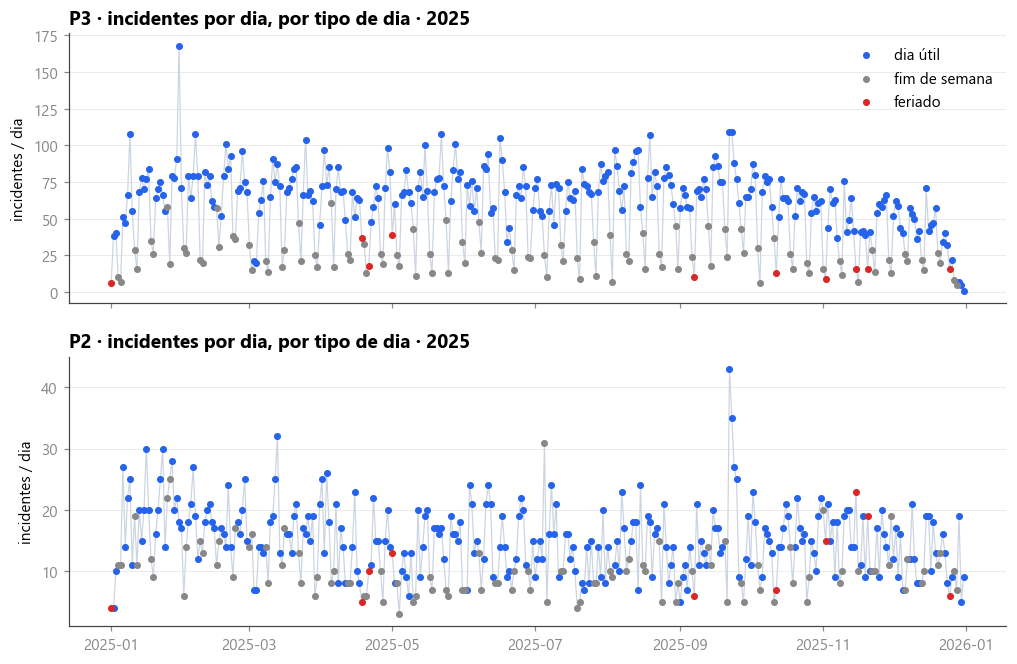

In [6]:
br_feriados = holidays.Brazil(years=2025)
paleta_dia = {'dia útil': COR['accent'], 'fim de semana': COR['cinza'], 'feriado': COR['danger']}

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (tag, s) in zip(axes, SERIES):
    eh_feriado = np.array([d.date() in br_feriados for d in s.index])
    eh_fds = s.index.dayofweek >= 5
    tipo = np.where(eh_feriado, 'feriado', np.where(eh_fds, 'fim de semana', 'dia útil'))
    ax.plot(s.index, s.values, color='#CBD5E1', lw=0.8, zorder=1)
    for t, c in paleta_dia.items():
        m = tipo == t
        ax.scatter(s.index[m], s.values[m], s=13, color=c, label=t, zorder=2)
    ax.set_title(f'{tag} · incidentes por dia, por tipo de dia · 2025', loc='left')
    ax.set_ylabel('incidentes / dia')
axes[0].legend(loc='upper right'); axes[1].margins(x=0.01)
salvar_fig(fig, '01_series_tipo_dia')
plt.show()

P3 tem média de 54,8 incidentes/dia (19.997 no ano) e P2, 14,1/dia (5.159). As duas séries têm o
mesmo formato: patamar estável em dia útil e queda em fim de semana e feriado. A diferença de
escala, de quase 4 vezes, sustenta modelar as duas separadamente.

### 4.2 Sazonalidade semanal

Média por dia da semana com intervalo de confiança de 95% da média (± 1,96 × erro padrão, sendo o
erro padrão o desvio dividido por √n). Sobreposição de intervalo é critério conservador e não
decide significância, então cada par de dias úteis também passa por um teste t de Welch.

=== P3 ===
      n  media  desvio  erro_padrao  IC95_+-
seg  52   64.1    19.2         2.66      5.2
ter  52   70.7    20.1         2.79      5.5
qua  53   68.0    20.0         2.75      5.4
qui  52   69.7    24.4         3.38      6.6
sex  52   62.8    14.8         2.05      4.0
sáb  52   31.0    11.7         1.62      3.2
dom  52   17.0     6.8         0.94      1.8
dias úteis, teste t de Welch: 1 de 10 pares com p < 0,05 | menor p = 0,0235 (ter x sex) | Bonferroni exigiria p < 0,0050

=== P2 ===
      n  media  desvio  erro_padrao  IC95_+-
seg  52   16.3     6.0         0.84      1.6
ter  52   16.3     5.5         0.77      1.5
qua  53   15.7     5.5         0.75      1.5
qui  52   16.3     6.6         0.92      1.8
sex  52   13.8     4.2         0.58      1.1
sáb  52   10.8     5.1         0.71      1.4
dom  52    9.6     4.2         0.58      1.1
dias úteis, teste t de Welch: 4 de 10 pares com p < 0,05 | menor p = 0,0101 (ter x sex) | Bonferroni exigiria p < 0,0050



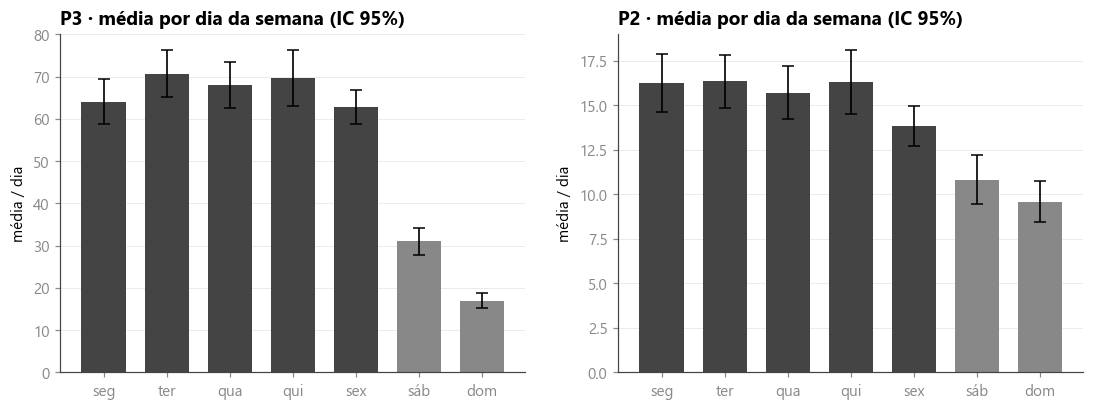

In [7]:
dias_lbl = ['seg', 'ter', 'qua', 'qui', 'sex', 'sáb', 'dom']

def stats_dia_semana(s):
    g = s.groupby(s.index.dayofweek)
    media, desvio, n = g.mean(), g.std(), g.count()
    erro = desvio / np.sqrt(n)
    ic95 = 1.96 * erro
    tabela = pd.DataFrame({'n': n.values, 'media': media.round(1).values,
                           'desvio': desvio.round(1).values, 'erro_padrao': erro.round(2).values,
                           'IC95_+-': ic95.round(1).values}, index=dias_lbl)
    return media, ic95, tabela

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (tag, s) in zip(axes, SERIES):
    media, ic95, tabela = stats_dia_semana(s)
    print(f'=== {tag} ===')
    print(tabela)

    # Sobreposição de IC não decide significância; o teste par a par decide.
    pares = list(itertools.combinations(range(5), 2))
    ps = sorted((stats.ttest_ind(s[s.index.dayofweek == a].values,
                                 s[s.index.dayofweek == b].values, equal_var=False)[1],
                 dias_lbl[a], dias_lbl[b]) for a, b in pares)
    n_sig = sum(1 for p, _, _ in ps if p < 0.05)
    print(f'dias úteis, teste t de Welch: {n_sig} de {len(pares)} pares com p < 0,05'
          f' | menor p = {fmt(ps[0][0], 4)} ({ps[0][1]} x {ps[0][2]})'
          f' | Bonferroni exigiria p < {fmt(0.05 / len(pares), 4)}\n')
    cores = [COR['cinza_esc']] * 5 + [COR['cinza']] * 2
    ax.bar(range(7), media.values, yerr=ic95.values, color=cores, width=0.7,
           error_kw=dict(ecolor=COR['preto'], elinewidth=1.1, capsize=4))
    ax.set_xticks(range(7)); ax.set_xticklabels(dias_lbl)
    ax.set_title(f'{tag} · média por dia da semana (IC 95%)', loc='left')
    ax.set_ylabel('média / dia')
salvar_fig(fig, '02_sazonalidade_semana')
plt.show()

Sábado e domingo formam um patamar próprio, muito abaixo dos dias úteis: no P3, 31,0 e 17,0 contra
uma faixa de 62,8 a 70,7.

Entre os dias úteis o quadro é mais sutil do que a leitura visual dos intervalos sugere. **A
sexta-feira é o menor dia útil nas duas séries** (P3 62,8 contra 70,7 da terça; P2 13,8 contra
16,3). No P2, 4 dos 10 pares dão p < 0,05 no teste de Welch, todos envolvendo a sexta; no P3,
apenas 1 par. Com correção de Bonferroni para as 10 comparações (p < 0,005), nenhum par sobrevive
em nenhuma das duas séries.

O contraste dominante é dia útil contra dia não útil, e o efeito da sexta é um sinal fraco e
consistente em cima disso. Isso não altera a configuração do modelo: a sazonalidade semanal do
Prophet estima um efeito por dia da semana, então a sexta entra de qualquer forma.

### 4.3 Baselines de referência (corte out-of-time)

Corte em 1º de outubro: treino de janeiro a setembro, teste de outubro a dezembro, sem que o
modelo enxergue o período de teste. Dois baselines congelados no corte: **sazonal-7**, que repete
a última semana observada dia a dia, e **média-7**, que repete a média dos últimos 7 dias. A
métrica é o MAE, em incidentes por dia.

P3  MAE sazonal-7: 20,53   |   MAE média-7: 22,69
P2  MAE sazonal-7: 6,72   |   MAE média-7: 4,28


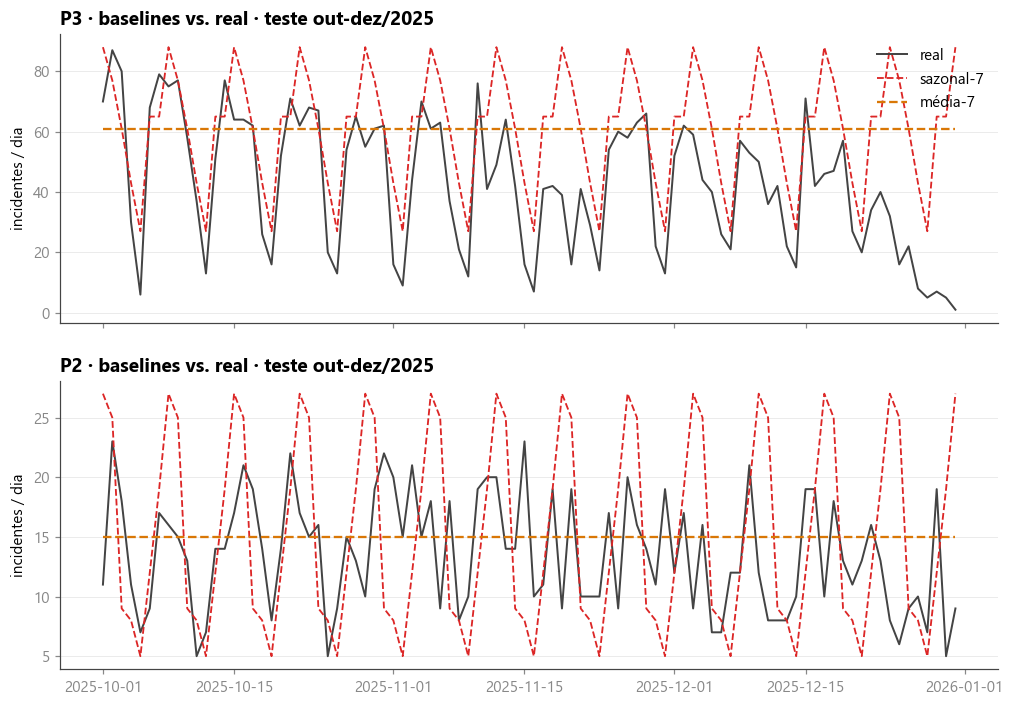

In [8]:
CORTE = pd.Timestamp('2025-10-01')

cortes = {}
fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, (tag, s) in zip(axes, SERIES):
    treino, teste = s[s.index < CORTE], s[s.index >= CORTE]
    ultima_semana = treino.iloc[-7:]
    mapa_dow = {d.dayofweek: v for d, v in ultima_semana.items()}
    prev_sazonal7 = np.array([mapa_dow[d.dayofweek] for d in teste.index])
    prev_media7 = np.full(len(teste), ultima_semana.mean())
    cortes[tag] = dict(treino=treino, teste=teste, sazonal7=prev_sazonal7, media7=prev_media7)

    print(f'{tag}  MAE sazonal-7: {fmt(mae(teste.values, prev_sazonal7))}   |   MAE média-7: {fmt(mae(teste.values, prev_media7))}')
    ax.plot(teste.index, teste.values, color=COR['cinza_esc'], lw=1.3, label='real')
    ax.plot(teste.index, prev_sazonal7, color=COR['danger'], lw=1.2, ls='--', label='sazonal-7')
    ax.plot(teste.index, prev_media7, color=COR['ambar'], lw=1.5, ls='--', label='média-7')
    ax.set_title(f'{tag} · baselines vs. real · teste out-dez/2025', loc='left')
    ax.set_ylabel('incidentes / dia')
axes[0].legend(loc='upper right'); axes[1].margins(x=0.01)
salvar_fig(fig, '03_baselines_teste')
plt.show()

O melhor baseline muda conforme a série. No P3 é o sazonal-7 (MAE 20,53 contra 22,69 da média-7),
porque o padrão semanal é forte. No P2 é a média-7 (4,28 contra 6,72): com volume baixo, repetir
uma semana específica dia a dia copia o ruído dela junto. Esses dois valores são a régua que o
Prophet precisa bater.

### 4.4 Prophet contra os baselines

Configuração: sazonalidade semanal ligada e anual desligada (um ano de dado denso não permite
estimar ciclo anual), feriados nacionais via `add_country_holidays('BR')`, banda de 80% e
previsões truncadas em zero.

P3  Prophet MAE 19,96  |  melhor baseline 20,53  ->  supera o melhor baseline


P2  Prophet MAE 3,67  |  melhor baseline 4,28  ->  supera o melhor baseline


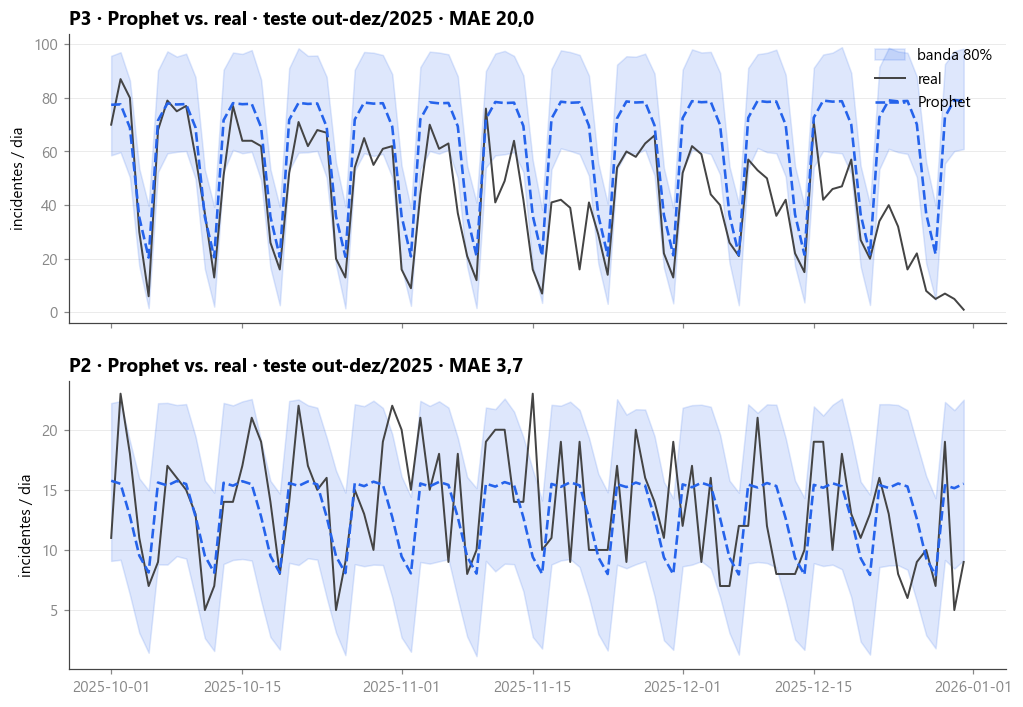

In [9]:
def treina_prophet(serie_treino):
    d = pd.DataFrame({'ds': serie_treino.index, 'y': serie_treino.values})
    m = Prophet(weekly_seasonality=True, yearly_seasonality=False,
                daily_seasonality=False, interval_width=0.80)
    m.add_country_holidays(country_name='BR')
    m.fit(d)
    return m

fig, axes = plt.subplots(2, 1, figsize=(11, 7.5), sharex=True)
for ax, (tag, s) in zip(axes, SERIES):
    c = cortes[tag]
    m = treina_prophet(c['treino'])
    fc = prever(m, c['teste'].index)
    yhat = fc['yhat'].clip(lower=0).to_numpy()
    banda_lo = fc['yhat_lower'].clip(lower=0).to_numpy()
    banda_hi = fc['yhat_upper'].clip(lower=0).to_numpy()

    mae_prophet = mae(c['teste'].values, yhat)
    melhor_baseline = min(mae(c['teste'].values, c['sazonal7']), mae(c['teste'].values, c['media7']))
    veredito = 'supera o melhor baseline' if mae_prophet < melhor_baseline else 'não supera o baseline'
    print(f'{tag}  Prophet MAE {fmt(mae_prophet)}  |  melhor baseline {fmt(melhor_baseline)}  ->  {veredito}')

    ax.fill_between(c['teste'].index, banda_lo, banda_hi, color=COR['accent'], alpha=0.15, label='banda 80%')
    ax.plot(c['teste'].index, c['teste'].values, color=COR['cinza_esc'], lw=1.3, label='real')
    ax.plot(c['teste'].index, yhat, color=COR['accent'], lw=1.7, ls='--', label='Prophet')
    ax.set_title(f'{tag} · Prophet vs. real · teste out-dez/2025 · MAE {fmt(mae_prophet, 1)}', loc='left')
    ax.set_ylabel('incidentes / dia')
axes[0].legend(loc='upper right'); axes[1].margins(x=0.01)
salvar_fig(fig, '04_prophet_teste')
plt.show()

No mesmo corte, o Prophet supera o melhor baseline nas duas séries: **P3 com MAE 19,96 contra
20,53, e P2 com 3,67 contra 4,28**. A previsão acompanha o padrão semanal do real.

### 4.5 Componentes do modelo

`plot_components` decompõe a previsão nas parcelas que, somadas, a formam: tendência, efeito de
feriados e padrão semanal.

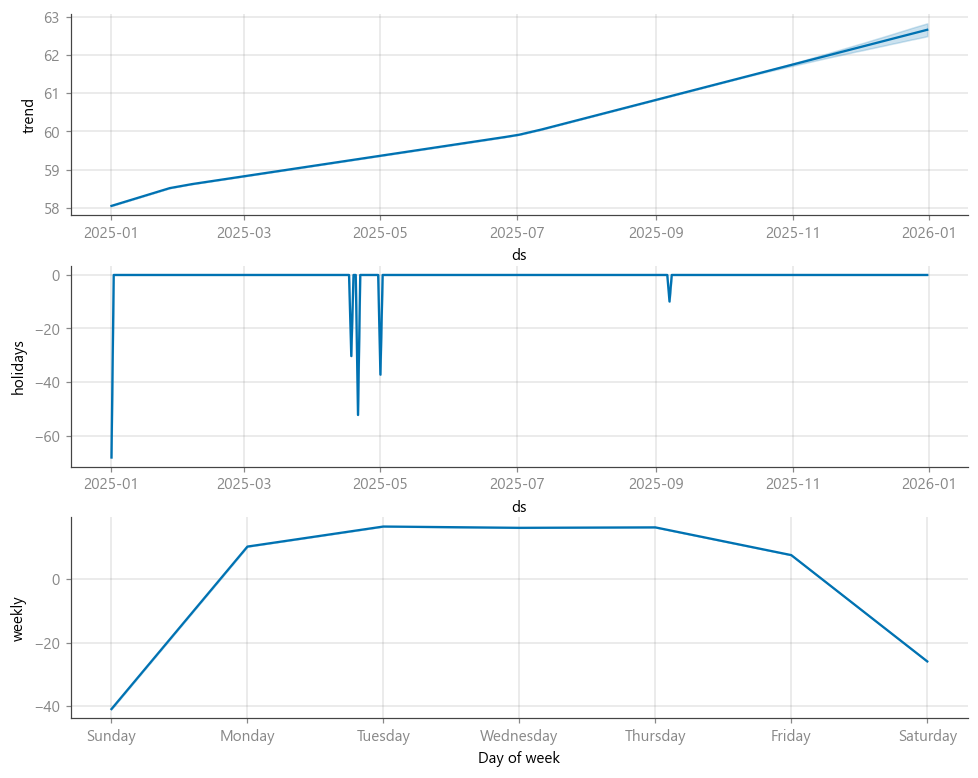

In [10]:
m_p3 = treina_prophet(cortes['P3']['treino'])
fc_p3 = prever(m_p3, idx_2025)

fig = m_p3.plot_components(fc_p3)
fig.set_size_inches(9, 7)
salvar_fig(fig, '05_componentes_p3')
plt.show()

O padrão semanal domina a forma da previsão, com a queda de sábado e domingo, seguido do efeito
negativo dos feriados. A tendência é quase plana, coerente com uma série estável ao longo do ano.

### 4.6 Sensibilidade de parâmetros

Três configurações treinadas no P3 e avaliadas no treino e no teste. Queda no erro de treino com
alta no de teste caracteriza overfitting, e o teste, que o modelo não viu, é o critério.

In [11]:
def testa_config(nome, **kwargs):
    c = cortes['P3']
    m = Prophet(weekly_seasonality=True, yearly_seasonality=False,
                daily_seasonality=False, interval_width=0.80, **kwargs)
    m.add_country_holidays(country_name='BR')
    m.fit(pd.DataFrame({'ds': c['treino'].index, 'y': c['treino'].values}))
    prev_treino = prever(m, c['treino'].index)['yhat'].clip(lower=0).to_numpy()
    prev_teste = prever(m, c['teste'].index)['yhat'].clip(lower=0).to_numpy()
    return {'config': nome,
            'MAE_treino': round(mae(c['treino'].values, prev_treino), 2),
            'MAE_teste':  round(mae(c['teste'].values,  prev_teste), 2)}

experimentos = [
    testa_config('1. padrão (aditivo)'),
    testa_config('2. multiplicativo', seasonality_mode='multiplicative'),
    testa_config('3. flexibilidade alta', changepoint_prior_scale=1.0, seasonality_prior_scale=25.0),
]
print(pd.DataFrame(experimentos).to_string(index=False))

               config  MAE_treino  MAE_teste
  1. padrão (aditivo)       10.23      19.96
    2. multiplicativo       10.23      20.61
3. flexibilidade alta        9.50      26.13


A configuração padrão dá o melhor teste, 19,96. O modo multiplicativo não altera o treino e piora
o teste para 20,61. A flexibilidade alta reduz o erro de treino de 10,23 para 9,50 e piora o teste
para 26,13, **que é o padrão clássico de overfitting**. A configuração padrão fica.

### 4.7 Rolling backtest

Protocolo de uso real: a cada origem, de setembro a dezembro e a cada 4 dias para percorrer todos
os dias da semana, o modelo treina com todo o histórico até ali e prevê D+1 a D+7, registrando o
erro por horizonte. Os resultados ficam em `rolling` e são reaproveitados na comparação final, o
que evita re-treinar.

P3  MAE médio D+1 a D+7 -> Prophet 11,76 | sazonal-7 11,25 | média-7 18,21


P2  MAE médio D+1 a D+7 -> Prophet 4,17 | sazonal-7 5,67 | média-7 4,91


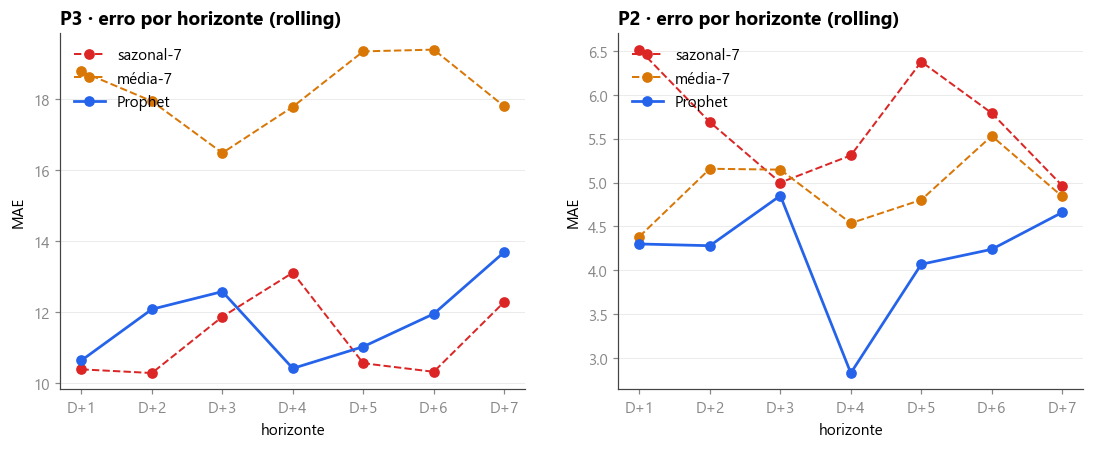

In [12]:
H = 7
origens = pd.date_range('2025-09-01', '2025-12-24', freq='4D')

def rolling_backtest(serie, origens, H=7):
    """MAE por horizonte (D+1..D+H) do Prophet e dos dois baselines, re-treinando a cada origem."""
    err_prophet = {h: [] for h in range(1, H + 1)}
    err_sazonal = {h: [] for h in range(1, H + 1)}
    err_media = {h: [] for h in range(1, H + 1)}
    for origem in origens:
        treino = serie[serie.index <= origem]
        datas = pd.date_range(origem + pd.Timedelta(days=1), periods=H, freq='D')
        real = serie.reindex(datas)
        if real.isna().any():
            continue
        m = treina_prophet(treino)
        prev = prever(m, datas)['yhat'].clip(lower=0).to_numpy()
        ultima_semana = treino.iloc[-7:]
        mapa_dow = {d.dayofweek: v for d, v in ultima_semana.items()}
        prev_sazonal = np.array([mapa_dow[d.dayofweek] for d in datas])
        prev_media = np.full(H, ultima_semana.mean())
        for i, h in enumerate(range(1, H + 1)):
            err_prophet[h].append(abs(real.values[i] - prev[i]))
            err_sazonal[h].append(abs(real.values[i] - prev_sazonal[i]))
            err_media[h].append(abs(real.values[i] - prev_media[i]))
    por_h = lambda e: [np.mean(e[h]) for h in range(1, H + 1)]
    return {'prophet': por_h(err_prophet), 'sazonal7': por_h(err_sazonal), 'media7': por_h(err_media)}

rolling = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
horizontes = list(range(1, H + 1))
for ax, (tag, s) in zip(axes, SERIES):
    r = rolling_backtest(s, origens, H)
    rolling[tag] = r
    print(f'{tag}  MAE médio D+1 a D+7 -> Prophet {fmt(np.mean(r["prophet"]))} | '
          f'sazonal-7 {fmt(np.mean(r["sazonal7"]))} | média-7 {fmt(np.mean(r["media7"]))}')
    ax.plot(horizontes, r['sazonal7'], color=COR['danger'], marker='o', lw=1.3, ls='--', label='sazonal-7')
    ax.plot(horizontes, r['media7'], color=COR['ambar'], marker='o', lw=1.3, ls='--', label='média-7')
    ax.plot(horizontes, r['prophet'], color=COR['accent'], marker='o', lw=1.8, label='Prophet')
    ax.set_xticks(horizontes); ax.set_xticklabels([f'D+{h}' for h in horizontes])
    ax.set_title(f'{tag} · erro por horizonte (rolling)', loc='left')
    ax.set_ylabel('MAE'); ax.set_xlabel('horizonte'); ax.legend(loc='upper left')
salvar_fig(fig, '06_rolling_horizonte')
plt.show()

No P2 o Prophet lidera: 4,17 contra 5,67 do sazonal-7 e 4,91 da média-7. No P3, Prophet (11,76) e
sazonal-7 (11,25) ficam no mesmo patamar, com a média-7 atrás (18,21).

**O erro varia pouco de D+1 a D+7 nas duas séries.** Como o sinal previsível é o padrão semanal,
que é fixo, prever o sétimo dia custa quase o mesmo que prever o primeiro.

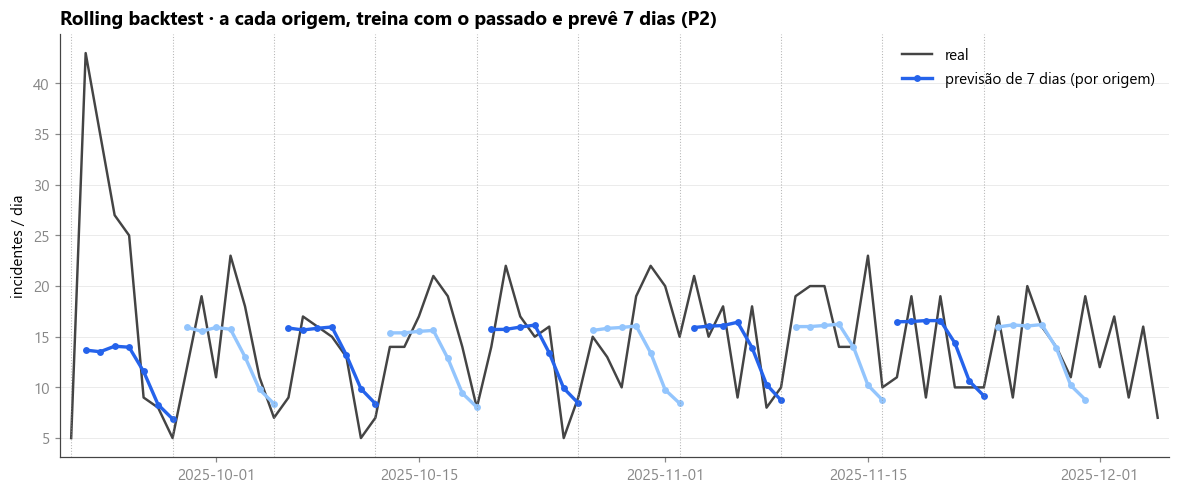

In [13]:
# Visualização do mecanismo: a cada origem, o modelo treina com o passado e prevê 7 dias
serie_p2_full = pd.concat([cortes['P2']['treino'], cortes['P2']['teste']])
janela_ini, janela_fim = pd.Timestamp('2025-09-21'), pd.Timestamp('2025-12-05')
origens_viz = pd.date_range('2025-09-21', '2025-11-28', freq='7D')

recorte = serie_p2_full[(serie_p2_full.index >= janela_ini) & (serie_p2_full.index <= janela_fim)]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(recorte.index, recorte.values, color=COR['cinza_esc'], lw=1.6, label='real', zorder=1)
cores_seg = [COR['accent'], '#93C5FD']
for i, origem in enumerate(origens_viz):
    treino = serie_p2_full[serie_p2_full.index <= origem]
    datas = pd.date_range(origem + pd.Timedelta(days=1), periods=7, freq='D')
    m = treina_prophet(treino)
    prev = prever(m, datas)['yhat'].clip(lower=0).to_numpy()
    ax.axvline(origem, color=COR['cinza'], ls=':', lw=0.7, alpha=0.6)
    ax.plot(datas, prev, color=cores_seg[i % 2], lw=2.2, marker='o', ms=3.5, zorder=2,
            label='previsão de 7 dias (por origem)' if i == 0 else None)
ax.set_title('Rolling backtest · a cada origem, treina com o passado e prevê 7 dias (P2)', loc='left')
ax.set_ylabel('incidentes / dia'); ax.legend(loc='upper right'); ax.margins(x=0.01)
salvar_fig(fig, '07_rolling_mecanismo')
plt.show()

### 4.8 Modelo alternativo: regressão linear de calendário

Features por dia: indicadores de dia da semana, indicador de feriado e as defasagens de 7 e 14
dias. A regressão aprende um peso por feature e a previsão é a soma ponderada. Os pesos do P3 são
exibidos para leitura direta do efeito de cada variável.

In [14]:
def monta_features(serie):
    dow = pd.Series(serie.index.dayofweek, index=serie.index)
    F = pd.get_dummies(dow, prefix='dow').astype(float)
    F['feriado'] = np.array([1.0 if d.date() in br_feriados else 0.0 for d in serie.index])
    F['lag7'] = serie.shift(7).values
    F['lag14'] = serie.shift(14).values
    F['y'] = serie.values
    return F

def rolling_regressao(serie, origens, H=7):
    """Mesmo protocolo do rolling_backtest, para a regressão de features."""
    F = monta_features(serie)
    Xcols = [c for c in F.columns if c != 'y']
    err = {h: [] for h in range(1, H + 1)}
    for origem in origens:
        datas = pd.date_range(origem + pd.Timedelta(days=1), periods=H, freq='D')
        if serie.reindex(datas).isna().any():
            continue
        treino = F[(F.index <= origem) & F.notna().all(axis=1)]
        m = LinearRegression().fit(treino[Xcols], treino['y'])
        prev = np.clip(m.predict(F.reindex(datas)[Xcols]), 0, None)
        real = serie.reindex(datas).values
        for i, h in enumerate(range(1, H + 1)):
            err[h].append(abs(real[i] - prev[i]))
    return [np.mean(err[h]) for h in range(1, H + 1)]

# Pesos aprendidos no P3 (ajuste com o ano completo, apenas para leitura dos efeitos)
F_p3 = monta_features(serie_p3)
treino_full = F_p3[F_p3.notna().all(axis=1)]
Xcols = [c for c in F_p3.columns if c != 'y']
reg_p3 = LinearRegression().fit(treino_full[Xcols], treino_full['y'])
print('Pesos aprendidos (P3):')
print(pd.Series(reg_p3.coef_, index=Xcols).round(2).to_string())
print(f'intercepto: {reg_p3.intercept_:.1f}')

Pesos aprendidos (P3):
dow_0       4.73
dow_1       7.91
dow_2       7.12
dow_3       8.54
dow_4       4.60
dow_5     -13.02
dow_6     -19.87
feriado   -25.68
lag7        0.27
lag14       0.18
intercepto: 30.9


Os pesos são legíveis: sábado (−13,0) e domingo (−19,9) puxam para baixo, o feriado é o maior
efeito negativo (−25,7) e as defasagens de 7 e 14 dias entram com peso pequeno (0,27 e 0,18),
capturando o nível recente da série. O modelo chega por outro caminho à mesma conclusão: o sinal
disponível é o calendário.

### 4.9 Comparação final

Prophet e os dois baselines vêm do rolling backtest da 4.7, com as mesmas origens; a regressão de
calendário é avaliada aqui sob o mesmo protocolo. Os dois baselines aparecem no gráfico porque o
mais forte muda conforme a série, e comparar o modelo apenas com o mais fraco inflaria o ganho.

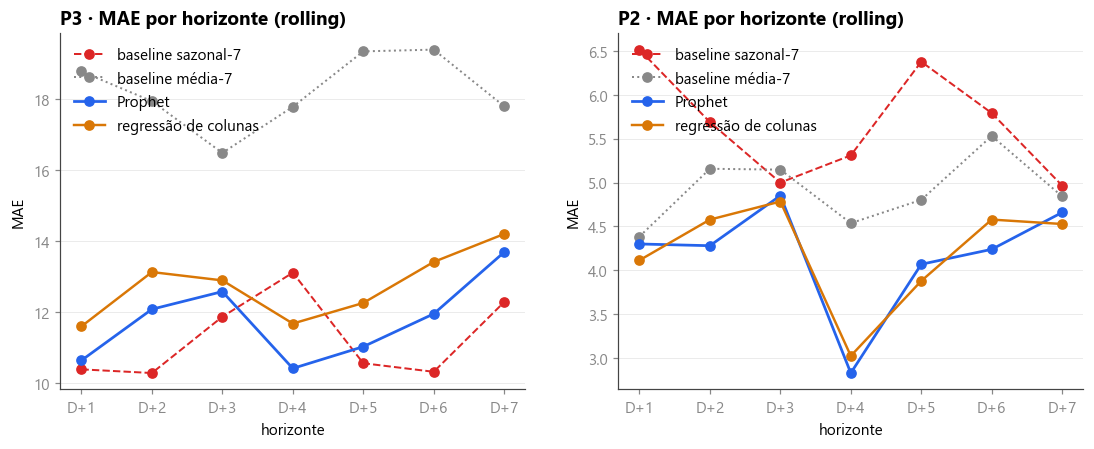

MAE médio D+1 a D+7 (rolling backtest):
prioridade  sazonal-7  média-7  Prophet  regressão de colunas  melhor baseline  ganho do Prophet %
        P3       11.3     18.2     11.8                  12.7             11.3                -4.5
        P2        5.7      4.9      4.2                   4.2              4.9                15.1

O ganho do Prophet é medido contra o MELHOR baseline de cada série, não contra o mais fraco.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
resumo = []
for ax, (tag, s) in zip(axes, SERIES):
    r = rolling[tag]
    mae_regressao = rolling_regressao(s, origens, H)
    melhor_base = min(np.mean(r['sazonal7']), np.mean(r['media7']))
    ganho = (melhor_base - np.mean(r['prophet'])) / melhor_base * 100
    resumo.append({'prioridade': tag,
                   'sazonal-7': round(np.mean(r['sazonal7']), 1),
                   'média-7': round(np.mean(r['media7']), 1),
                   'Prophet': round(np.mean(r['prophet']), 1),
                   'regressão de colunas': round(np.mean(mae_regressao), 1),
                   'melhor baseline': round(melhor_base, 1),
                   'ganho do Prophet %': round(ganho, 1)})
    ax.plot(horizontes, r['sazonal7'], color=COR['danger'], marker='o', lw=1.3, ls='--', label='baseline sazonal-7')
    ax.plot(horizontes, r['media7'], color=COR['cinza'], marker='o', lw=1.3, ls=':', label='baseline média-7')
    ax.plot(horizontes, r['prophet'], color=COR['accent'], marker='o', lw=1.8, label='Prophet')
    ax.plot(horizontes, mae_regressao, color=COR['ambar'], marker='o', lw=1.6, label='regressão de colunas')
    ax.set_xticks(horizontes); ax.set_xticklabels([f'D+{h}' for h in horizontes])
    ax.set_title(f'{tag} · MAE por horizonte (rolling)', loc='left')
    ax.set_ylabel('MAE'); ax.set_xlabel('horizonte'); ax.legend(loc='upper left')
salvar_fig(fig, '08_comparacao_final')
plt.show()

print('MAE médio D+1 a D+7 (rolling backtest):')
print(pd.DataFrame(resumo).to_string(index=False))
print()
print('O ganho do Prophet é medido contra o MELHOR baseline de cada série, não contra o mais fraco.')

No P2, Prophet e regressão de calendário empatam em 4,2 e superam os dois baselines. O melhor
baseline do P2 é a média-7 (4,9), então **o ganho do Prophet é de 15,1%**; contra o sazonal-7
(5,7) seria 26%, e é o primeiro que vale. No P3 os três operam entre 11,3 e 12,7, com leve
vantagem do baseline sazonal-7.

Três métodos com o mesmo conjunto de informação convergem para o mesmo erro. O sinal previsível,
padrão semanal e feriados, já está capturado por todos, e o resíduo é ruído que o dado disponível
não explica. Trocar de algoritmo mantendo as mesmas variáveis não deve mudar esse patamar.

### 4.10 Verificações de robustez

Quatro checagens antes de fechar o modelo: calibração da banda de confiança, natureza da queda de
novembro e dezembro, relação entre volume e quebra de OLA, e o padrão de acúmulo descrito pela
Locaweb na mentoria.

#### 4.10.1 Cobertura empírica da banda de 80%

A banda promete conter o valor real em 80% dos dias. A checagem conta quantos dias do período de
teste caem dentro dela.

In [16]:
for tag, s in SERIES:
    c = cortes[tag]
    m = treina_prophet(c['treino'])
    fc = prever(m, c['teste'].index)
    lo = fc['yhat_lower'].clip(lower=0).to_numpy()
    hi = fc['yhat_upper'].clip(lower=0).to_numpy()
    dentro = ((c['teste'].values >= lo) & (c['teste'].values <= hi)).mean() * 100
    print(f'{tag}: {fmt(dentro, 1)}% dos {len(c["teste"])} dias de teste dentro da banda (nominal 80%)')

P3: 60,9% dos 92 dias de teste dentro da banda (nominal 80%)


P2: 84,8% dos 92 dias de teste dentro da banda (nominal 80%)


No P2 a cobertura fica acima do nominal, em 84,8%, ou seja, a banda é conservadora. **No P3 fica
em 60,9%, bem abaixo dos 80% prometidos**, o que significa que a banda subestima a incerteza no
período de teste. A causa aparece na verificação seguinte.

Sobre reprodutibilidade: o ajuste do Prophet é determinístico. O ponto previsto, o MAE e o
`sigma_obs` saem idênticos entre execuções e entre processos. A banda é que não vem do ajuste, e
sim de amostragem posterior, que consome o gerador aleatório do numpy. Por isso o notebook fixa a
semente antes de cada previsão, e o valor acima coincide com o de um script isolado que refaz a
mesma conta fora do notebook. Ainda assim, a cobertura é uma estimativa sobre 92 dias, com ruído
de amostragem de alguns pontos percentuais: o que vale é a leitura, P2 acima e P3 abaixo do
nominal, e não a casa decimal.

#### 4.10.2 A queda de novembro e dezembro é efeito real ou censura de dados?

O volume elegível cai de 2.126 em outubro para 1.634 em novembro e 1.423 em dezembro, dentro do
período de teste. Se a causa fosse censura à direita, isto é, incidentes ainda sem classificação
final no momento da extração, o erro do teste estaria sendo medido contra um real artificialmente
baixo. Três verificações: completude do arquivo, distribuição dentro do mês e parcela elegível
sobre o total.

In [17]:
df_bruto = pd.read_excel(RAIZ / 'assets' / 'Materal LocalWeb' / 'LW-DATASET.xlsx',
                         sheet_name='Dataset Geral')
for col in ('Aberto', 'Encerrado'):
    df_bruto[col] = pd.to_datetime(df_bruto[col], errors='coerce')

# (a) o arquivo está completo? incidente sem 'Encerrado' indicaria registro ainda aberto na extração
abertos = int(df_bruto['Encerrado'].isna().sum())
print(f'registros sem data de encerramento: {abertos}  |  último encerramento: {df_bruto["Encerrado"].max():%d/%m/%Y %H:%M}')

# (b) distribuição dentro do mês: censura concentraria a perda no fim de dezembro
df_2025 = df_kpi[df_kpi['ano'] == 2025].copy()
df_2025['dia_do_mes'] = pd.to_datetime(df_2025['dia']).dt.day
df_2025['mes_num'] = pd.to_datetime(df_2025['dia']).dt.month
faixas = pd.cut(df_2025['dia_do_mes'], [0, 10, 20, 31], labels=['1 a 10', '11 a 20', '21 a 31'])
print('\nelegíveis por terço do mês:')
print(df_2025[df_2025['mes_num'].isin([11, 12])].groupby([df_2025['mes_num'], faixas], observed=True)
      .size().unstack().to_string())

# (c) a parcela elegível sobre o total, mês a mês
df_bruto['mes'] = df_bruto['Aberto'].dt.to_period('M')
total_mes = df_bruto[df_bruto['Aberto'].dt.year == 2025].groupby('mes').size()
eleg_mes = df_2025.assign(mes=pd.to_datetime(df_2025['dia']).dt.to_period('M')).groupby('mes').size()
comp = pd.DataFrame({'total': total_mes, 'elegivel': eleg_mes})
comp['share_%'] = (comp['elegivel'] / comp['total'] * 100).round(1)
print('\nparcela elegível sobre o total, por mês:')
print(comp.to_string())

registros sem data de encerramento: 0  |  último encerramento: 31/12/2025 23:45

elegíveis por terço do mês:
dia_do_mes  1 a 10  11 a 20  21 a 31
mes_num                             
11             562      516      556
12             589      529      305

parcela elegível sobre o total, por mês:
         total  elegivel  share_%
mes                              
2025-01   3714      2357     63.5
2025-02   3553      2282     64.2
2025-03   3588      2130     59.4
2025-04   3202      2072     64.7
2025-05   3329      2247     67.5
2025-06   3558      2105     59.2
2025-07   3448      2126     61.7
2025-08   3996      2330     58.3
2025-09  21561      2324     10.8
2025-10  23017      2126      9.2
2025-11  21524      1634      7.6
2025-12  27321      1423      5.2


**A censura está descartada.** O arquivo tem data de encerramento em 100% dos registros e o último
encerramento é 31/12/2025 23:45.

A queda tem duas causas reais. A parada de fim de ano aparece no último terço de dezembro, que cai
de 556 em novembro para 305, cerca de 45%. E a parcela elegível sobre o total despenca ao longo do
ano, de 58,3% em agosto para 5,2% em dezembro, por efeito da expansão do monitoramento: dezembro
tem o maior total do ano (27.321) e mesmo assim o menor elegível.

Como o treino cobre janeiro a setembro, essa mudança de nível estava fora do que o modelo podia
antecipar, o que explica parte do erro no teste e a sub-cobertura da banda no P3.

#### 4.10.3 O volume previsto tem relação com a quebra de OLA?

Se dias de volume alto não concentram mais quebras, prever volume não contribui para reduzir
violações. O teste usa apenas dias úteis, para que o contraste entre dia útil e fim de semana não
produza correlação espúria.

In [18]:
df_v = df_bruto[(df_bruto['Entrou para KPI?'] == 'SIM') & (df_bruto['Aberto'].dt.year == 2025)].copy()
df_v['dia'] = df_v['Aberto'].dt.normalize()
df_v['quebrou'] = (df_v['KPI Violado?'] == 'SIM').astype(int)
diario = (df_v.groupby('dia').agg(volume=('quebrou', 'size'), quebras=('quebrou', 'sum'))
          .reindex(idx_2025, fill_value=0))
diario['dia_util'] = [(d.dayofweek < 5) and (d.date() not in br_feriados) for d in diario.index]
uteis = diario[diario['dia_util']]

r, p = stats.pearsonr(uteis['volume'], uteis['quebras'])
print(f'dias úteis analisados: {len(uteis)}  |  quebras no período: {int(uteis["quebras"].sum())}')
print(f'correlação volume x quebras por dia: r = {fmt(r, 3)} (p = {fmt(p, 4)})  |  R2 = {fmt(r**2, 3)}')

quartis = pd.qcut(uteis['volume'], 4, labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)'], duplicates='drop')
tab = uteis.groupby(quartis, observed=True).agg(dias=('volume', 'size'), volume_medio=('volume', 'mean'),
                                                quebras=('quebras', 'sum'))
tab['quebras_por_dia'] = (tab['quebras'] / tab['dias']).round(2)
tab['taxa_%'] = (tab['quebras'] / (tab['volume_medio'] * tab['dias']) * 100).round(2)
print()
print(tab.round(1).to_string())

dias úteis analisados: 255  |  quebras no período: 181
correlação volume x quebras por dia: r = 0,159 (p = 0,0108)  |  R2 = 0,025

            dias  volume_medio  quebras  quebras_por_dia  taxa_%
volume                                                          
Q1 (menor)    64          58.0       31              0.5     0.8
Q2            69          79.6       48              0.7     0.9
Q3            61          90.2       54              0.9     1.0
Q4 (maior)    61         110.0       48              0.8     0.7


A relação existe e é significativa, porém fraca: **r = 0,159 (p = 0,011), R² = 0,025**. Em valor
absoluto, os dias do quartil de maior volume registram cerca de 60% mais quebras que os do menor
(0,8 contra 0,5 por dia), mas a taxa de quebra fica praticamente constante entre os quartis, de
0,7% a 1,0%, e o volume explica 2,5% da variação diária no número de quebras.

Consequência para o produto: a previsão de volume dimensiona carga e sustenta a projeção da meta
anual, mas não identifica qual incidente vai violar o prazo. Essa identificação exige um modelo
por incidente. A previsão de volume, sozinha, não deve ser apresentada como redutora direta de
violações.

#### 4.10.4 O padrão de acúmulo descrito pela Locaweb

Na mentoria, a Locaweb descreveu um padrão de acúmulo derrubando o OLA. A hipótese de cascata, de
incidentes pequenos escalando, já foi testada e refutada; o acúmulo em si nunca havia sido medido.

O backlog é a contagem de incidentes elegíveis abertos e ainda não resolvidos no fim de cada dia.
O teste usa apenas dias úteis, porque fim de semana acumula pendência sem gerar quebra e
produziria correlação espúria.

In [19]:
fim_do_dia = pd.Timedelta(hours=23, minutes=59)
# Incidente pendente é o que ainda não tem resolução; onde ela falta, o encerramento fecha a janela.
df_v['resolvido'] = (pd.to_datetime(df_v['Resolvido'], errors='coerce')
                     .fillna(pd.to_datetime(df_v['Encerrado'], errors='coerce')))

backlog = []
for dia in idx_2025:
    corte = dia + fim_do_dia
    aberto_e_pendente = (df_v['Aberto'] <= corte) & ((df_v['resolvido'] > corte) | df_v['resolvido'].isna())
    backlog.append(int(aberto_e_pendente.sum()))
diario['backlog'] = backlog
uteis = diario[diario['dia_util']]

r_b, p_b = stats.pearsonr(uteis['backlog'], uteis['quebras'])
rs_b, ps_b = stats.spearmanr(uteis['backlog'], uteis['quebras'])
backlog_medio = uteis['backlog'].mean()
print(f'backlog médio: {fmt(backlog_medio, 1)} incidentes pendentes por dia útil')
print(f'correlação backlog x quebras: Pearson r = {fmt(r_b, 3)} (p = {fmt(p_b, 4)}) | '
      f'Spearman = {fmt(rs_b, 3)} (p = {fmt(ps_b, 4)})')
for lag in (1, 2, 3):
    defasado = uteis['backlog'].shift(lag).fillna(uteis['backlog'].mean())
    r_l, p_l = stats.pearsonr(defasado, uteis['quebras'])
    print(f'  backlog de D-{lag} x quebras de hoje: r = {fmt(r_l, 3)} (p = {fmt(p_l, 4)})')

quartis_b = pd.qcut(uteis['backlog'], 4, labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4 (maior)'], duplicates='drop')
tab_b = uteis.groupby(quartis_b, observed=True).agg(dias=('backlog', 'size'),
                                                    backlog_medio=('backlog', 'mean'),
                                                    quebras=('quebras', 'sum'))
tab_b['quebras_por_dia'] = (tab_b['quebras'] / tab_b['dias']).round(2)
print()
print(tab_b.round(1).to_string())

backlog médio: 294,8 incidentes pendentes por dia útil
correlação backlog x quebras: Pearson r = -0,139 (p = 0,0266) | Spearman = -0,115 (p = 0,0666)
  backlog de D-1 x quebras de hoje: r = -0,137 (p = 0,0291)
  backlog de D-2 x quebras de hoje: r = -0,144 (p = 0,0214)
  backlog de D-3 x quebras de hoje: r = -0,141 (p = 0,0248)

            dias  backlog_medio  quebras  quebras_por_dia
backlog                                                  
Q1 (menor)    65           70.4       46              0.7
Q2            65          205.3       55              0.8
Q3            61          297.4       50              0.8
Q4 (maior)    64          611.0       30              0.5


**A hipótese não se sustenta na forma como o dado permite medir.** A correlação entre backlog e
quebras é levemente negativa e fraca (Pearson r = −0,139, p = 0,027; Spearman −0,115, p = 0,067),
e o sinal se mantém com defasagem de 1 a 3 dias. O quartil de maior backlog, com 611 pendentes em
média, registra 0,5 quebra por dia, contra 0,7 do quartil de menor backlog, com 70 pendentes.

Ressalva: o resultado diz que o backlog agregado por dia não prevê quebra nesta base, e não que o
acúmulo seja irrelevante na operação. Efeito por equipe específica ou por capacidade instalada não
é observável, porque o dataset não traz capacidade nem turno.

## 5. Conclusão

O modelo entregue é o **Prophet**, com sazonalidade semanal, feriados nacionais, banda de 80% e
previsões truncadas em zero. A escolha não vem de erro menor: no rolling backtest o Prophet lidera
no P2 (4,2 contra 4,9 do melhor baseline, 15,1% de ganho) e fica no mesmo patamar no P3 (11,8
contra 11,3). Vem das propriedades operacionais: intervalo de predição, feriados nativos e a mesma
configuração servindo as duas séries.

O erro divulgado é o do rolling backtest, **cerca de 4 incidentes/dia no P2 e 11 no P3**, sempre
acompanhado da cobertura observada da banda, de 84,8% no P2 e 60,9% no P3. A interface exibe a
previsão com a banda, nunca só o ponto.

O escopo do modelo é planejamento de capacidade e projeção da meta anual; identificar qual
incidente vai violar o prazo depende do modelo de risco por incidente. Com mais histórico elegível
seria possível reavaliar a sazonalidade anual, hoje desligada por falta de dado.